# Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import math
import seaborn as sns
import pickle
import copy

import torch
from torch import nn, Tensor

import time
import joblib

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

from sklearn.preprocessing import StandardScaler

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from fm.seed import set_seed
import fm.data as data
import fm.model as model
import fm.training as training
import fm.physics as physics
import fm.massesPlots as massesPlots
import fm.lossPlots as lossPlots
import fm.analysis as analysis
import fm.scaling_utils as scalingUtils

In [3]:
# for the plots :
import mplhep as hep

plt.style.use(hep.style.CMS)

plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 13,

    "lines.linewidth": 2,

    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",

    "legend.frameon": False,
})


# Utils

In [4]:
DATASET_TAG = "unbalanced"   # o balanced
PREPARED_DIR = "../results/prepared_splits"

SCALING_MODES = [
    "X_NONE__Y_NONE",
    "X_GLOBAL__Y_GLOBAL",
    "X_GLOBAL__Y_LOCAL",
    "X_LOCAL__Y_LOCAL",
    "X_NONE__Y_LOCAL",
]

CLASS_COL = "class"

In [5]:
tau1_cols = [
    "tau1_logpt", "tau1_eta", "tau1_phi", "tau1_mass",
    "tau1_dxy", "tau1_dz",
    "tau1_ptCorrPNet", "tau1_rawPNetVSjet", "tau1_rawDeepTau2018v2p5VSjet",
    "tau1_charge",
    "tau1_dM_0", "tau1_dM_1", "tau1_dM_2", "tau1_dM_10", "tau1_dM_11",
    "tau1_leadTkDeltaEta", "tau1_leadTkDeltaPhi", "tau1_leadTkPtOverTauPt",
]

tau2_cols = [
    "tau2_logpt", "tau2_eta", "tau2_phi", "tau2_mass",
    "tau2_dxy", "tau2_dz",
    "tau2_ptCorrPNet", "tau2_rawPNetVSjet", "tau2_rawDeepTau2018v2p5VSjet",
    "tau2_charge",
    "tau2_dM_0", "tau2_dM_1", "tau2_dM_2", "tau2_dM_10", "tau2_dM_11",
    "tau2_leadTkDeltaEta", "tau2_leadTkDeltaPhi", "tau2_leadTkPtOverTauPt", 
]

jet_cols = [
    "jet1_logpt", "jet1_eta", "jet1_phi", "jet1_mass",
    "jet2_logpt", "jet2_eta", "jet2_phi", "jet2_mass",
    "jet3_logpt", "jet3_eta", "jet3_phi", "jet3_mass",
]

met_cols = [
    "MET_logpt","MET_phi","MET_significance","MET_sumEt"
]

train_cols = (
    tau1_cols
    + tau2_cols
    + jet_cols
    + met_cols
)

y_cols = ["tau1_corr", "tau2_corr"]

# Loading & Preparing the DataFrames

In [6]:
with open("df_H_event.pkl", "rb") as f:
    df_H_event = pickle.load(f)

with open("df_DY_event.pkl", "rb") as f:
    df_DY_event = pickle.load(f)

In [9]:
# Creo i dataframe : 
#   1. All
#   2. Bilanciato

df_all = (
    pd.concat([df_DY_event, df_H_event], axis=0)
      .sample(frac=1.0, random_state=0)
      .reset_index(drop=True)
)

In [10]:
# -----------------------
# Split raw data
# -----------------------

df_all_train, df_all_val, df_all_test = data.split_df_once(df_all)
print("ALL splits")
print("train:", df_all_train.shape)
print("val  :", df_all_val.shape)
print("test :", df_all_test.shape)

ALL splits
train: (269880, 76)
val  : (33735, 76)
test : (33736, 76)


## Y Pre-Scaling

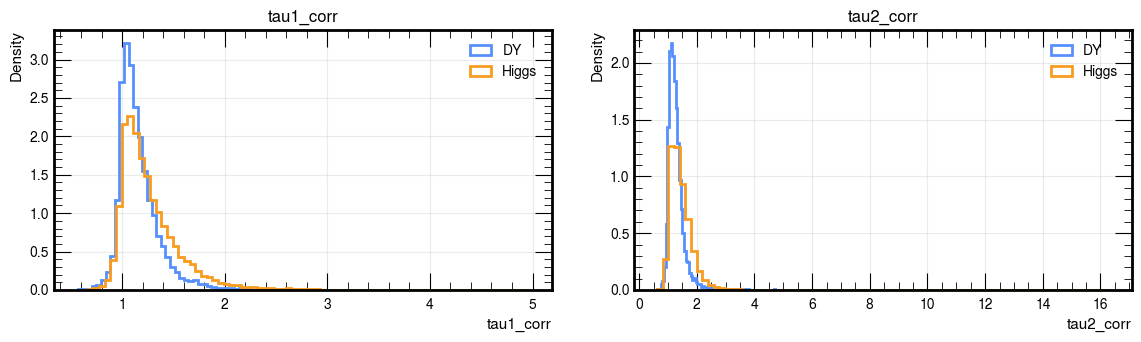

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, y_cols):
    mask_dy = df_all_test[CLASS_COL] == 0
    mask_h  = df_all_test[CLASS_COL] == 1

    ax.hist(
        df_all_test.loc[mask_dy, col],
        bins=80,
        histtype="step",
        linewidth=2,
        density=True,
        label="DY",
    )
    ax.hist(
        df_all_test.loc[mask_h, col],
        bins=80,
        histtype="step",
        linewidth=2,
        density=True,
        label="Higgs",
    )

    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

In [14]:
df_all_test.groupby(CLASS_COL)[y_cols].describe()

tau1_corr                                                              \
          count      mean       std       min       25%       50%       75%   
class                                                                         
0        8197.0  1.162894  0.221098  0.570404  1.030158  1.112298  1.238219   
1       25539.0  1.271129  0.308427  0.556695  1.068890  1.190998  1.387250   

                tau2_corr                                                    \
            max     count      mean       std       min       25%       50%   
class                                                                         
0      4.157386    8197.0  1.270212  0.291644  0.638042  1.094380  1.213112   
1      4.964631   25539.0  1.447156  0.411457  0.622211  1.172127  1.362853   

                            
            75%        max  
class                       
0      1.366448   5.245035  
1      1.624716  16.310534

## Y Post-Scaling

In [16]:
# ============================================================
# 1. Copie dei dataframe raw
# ============================================================
df_all_train_global = df_all_train.copy()
df_all_val_global   = df_all_val.copy()
df_all_test_global  = df_all_test.copy()

df_all_train_local = df_all_train.copy()
df_all_val_local   = df_all_val.copy()
df_all_test_local  = df_all_test.copy()

# ============================================================
# 2. GLOBAL scaling su y_cols
#    Fit solo sul train, poi transform su train/val/test
# ============================================================
y_scaler_global = StandardScaler()
y_scaler_global.fit(df_all_train[y_cols])

df_all_train_global.loc[:, y_cols] = y_scaler_global.transform(df_all_train[y_cols])
df_all_val_global.loc[:, y_cols]   = y_scaler_global.transform(df_all_val[y_cols])
df_all_test_global.loc[:, y_cols]  = y_scaler_global.transform(df_all_test[y_cols])

# ============================================================
# 3. LOCAL scaling su y_cols
#    Uno scaler per classe, fit sul train della singola classe
# ============================================================
y_scaler_local = {}

for cls in sorted(df_all_train[CLASS_COL].unique()):
    scaler = StandardScaler()
    mask_train = df_all_train[CLASS_COL] == cls
    scaler.fit(df_all_train.loc[mask_train, y_cols])
    y_scaler_local[cls] = scaler

    for df_src, df_dst in [
        (df_all_train, df_all_train_local),
        (df_all_val,   df_all_val_local),
        (df_all_test,  df_all_test_local),
    ]:
        mask = df_src[CLASS_COL] == cls
        df_dst.loc[mask, y_cols] = scaler.transform(df_src.loc[mask, y_cols])

In [17]:
print("GLOBAL by class")
print(df_all_test_global.groupby(CLASS_COL)[y_cols].agg(["mean", "std"]))

print("\nLOCAL by class")
print(df_all_test_local.groupby(CLASS_COL)[y_cols].agg(["mean", "std"]))

GLOBAL by class
      tau1_corr           tau2_corr          
           mean       std      mean       std
class                                        
0     -0.273932  0.754616 -0.347465  0.758664
1      0.095481  1.052675  0.112825  1.070337

LOCAL by class
      tau1_corr           tau2_corr          
           mean       std      mean       std
class                                        
0       0.00471  1.009807 -0.002607  1.016171
1       0.00597  0.999494  0.001676  1.024461


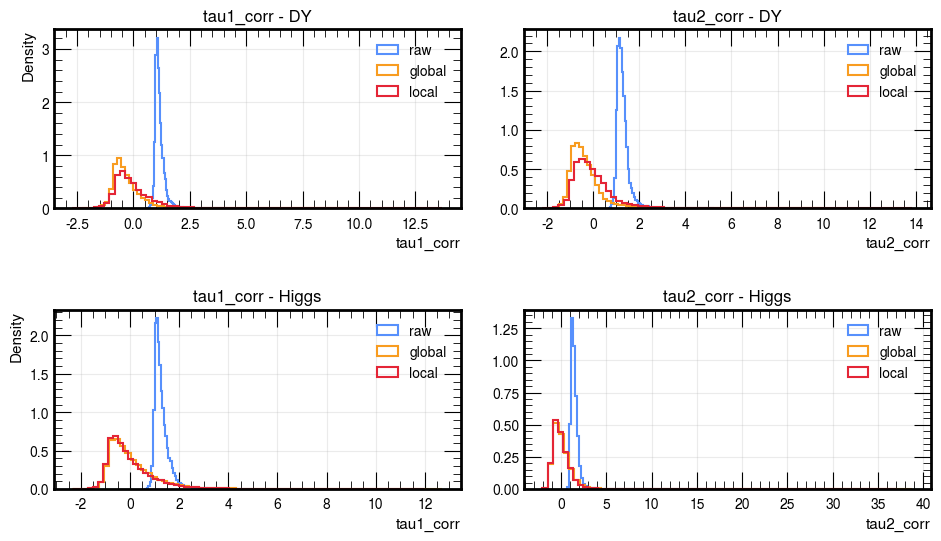

In [26]:
classes = {
    0: "DY",
    1: "Higgs",
}

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

for i, col in enumerate(y_cols):
    for j, cls in enumerate(classes):

        ax = axes[j, i]

        mask_raw = df_all_test[CLASS_COL] == cls
        mask_glb = df_all_test_global[CLASS_COL] == cls
        mask_loc = df_all_test_local[CLASS_COL] == cls

        ax.hist(
            df_all_test.loc[mask_raw, col],
            bins=70,
            density=True,
            histtype="step",
            lw=1.5,
            label="raw",
        )

        ax.hist(
            df_all_test_global.loc[mask_glb, col],
            bins=70,
            density=True,
            histtype="step",
            lw=1.5,
            label="global",
        )

        ax.hist(
            df_all_test_local.loc[mask_loc, col],
            bins=70,
            density=True,
            histtype="step",
            lw=1.5,
            label="local",
        )

        ax.set_title(f"{col} - {classes[cls]}")
        ax.set_xlabel(col)

        if i == 0:
            ax.set_ylabel("Density")

        ax.legend()

plt.tight_layout()
plt.show()

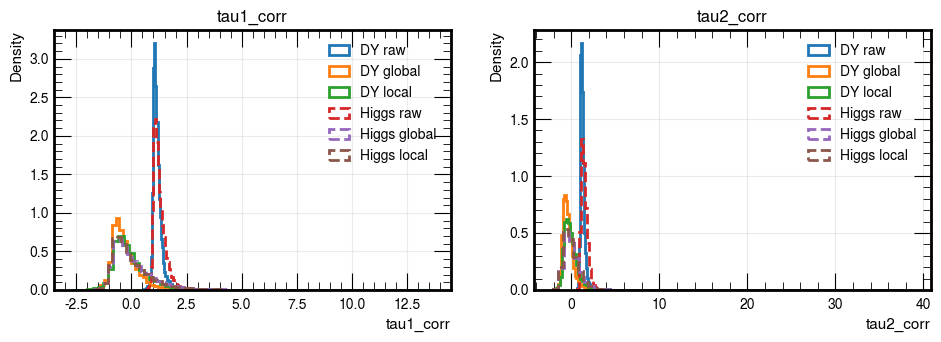

In [34]:
classes = {
    0: ("DY", "-"),
    1: ("Higgs", "--"),
}

colors = {
    "DY": {
        "raw": "#1f77b4",     # blu
        "global": "#ff7f0e",  # arancione
        "local": "#2ca02c",   # verde
    },
    "Higgs": {
        "raw": "#d62728",     # rosso
        "global": "#9467bd",  # viola
        "local": "#8c564b",   # marrone
    },
}

fig, axes = plt.subplots(1, 2, figsize=(10,4))

for i, col in enumerate(y_cols):

    ax = axes[i]

    for cls, (label, ls) in classes.items():

        mask_raw = df_all_test[CLASS_COL] == cls
        mask_glb = df_all_test_global[CLASS_COL] == cls
        mask_loc = df_all_test_local[CLASS_COL] == cls

        ax.hist(
            df_all_test.loc[mask_raw, col],
            bins=70,
            density=True,
            histtype="step",
            lw=2,
            linestyle=ls,
            color=colors[label]["raw"],
            label=f"{label} raw",
        )

        ax.hist(
            df_all_test_global.loc[mask_glb, col],
            bins=70,
            density=True,
            histtype="step",
            lw=2,
            linestyle=ls,
            color=colors[label]["global"],
            label=f"{label} global",
        )

        ax.hist(
            df_all_test_local.loc[mask_loc, col],
            bins=70,
            density=True,
            histtype="step",
            lw=2,
            linestyle=ls,
            color=colors[label]["local"],
            label=f"{label} local",
        )

    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

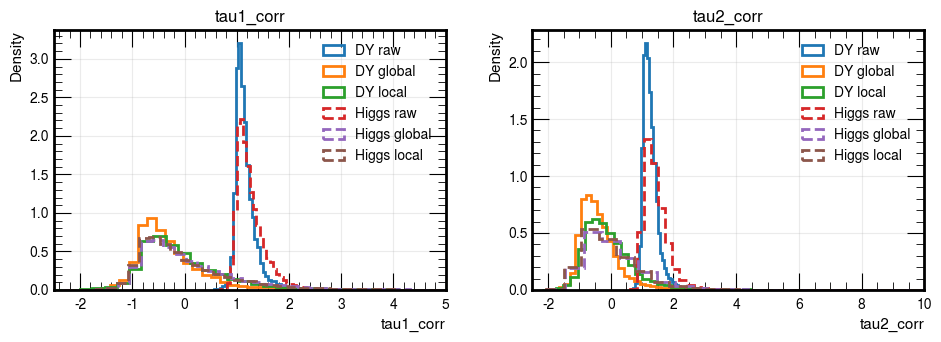

In [35]:
classes = {
    0: ("DY", "-"),
    1: ("Higgs", "--"),
}

colors = {
    "DY": {
        "raw": "#1f77b4",
        "global": "#ff7f0e",
        "local": "#2ca02c",
    },
    "Higgs": {
        "raw": "#d62728",
        "global": "#9467bd",
        "local": "#8c564b",
    },
}

fig, axes = plt.subplots(1, 2, figsize=(10,4))

for i, col in enumerate(y_cols):

    ax = axes[i]

    for cls, (label, ls) in classes.items():

        mask_raw = df_all_test[CLASS_COL] == cls
        mask_glb = df_all_test_global[CLASS_COL] == cls
        mask_loc = df_all_test_local[CLASS_COL] == cls

        ax.hist(
            df_all_test.loc[mask_raw, col],
            bins=70, density=True, histtype="step",
            lw=2, linestyle=ls,
            color=colors[label]["raw"],
            label=f"{label} raw",
        )

        ax.hist(
            df_all_test_global.loc[mask_glb, col],
            bins=70, density=True, histtype="step",
            lw=2, linestyle=ls,
            color=colors[label]["global"],
            label=f"{label} global",
        )

        ax.hist(
            df_all_test_local.loc[mask_loc, col],
            bins=70, density=True, histtype="step",
            lw=2, linestyle=ls,
            color=colors[label]["local"],
            label=f"{label} local",
        )

    # Range asse x
    if i == 0:  # tau1
        ax.set_xlim(-2.5, 5)
    elif i == 1:  # tau2
        ax.set_xlim(-2.5, 10)

    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

In [31]:
mean_raw = (
    df_all_test
    .groupby(CLASS_COL)[y_cols]
    .mean()
    .reset_index()
    .assign(scaling="raw")
)

mean_global = (
    df_all_test_global
    .groupby(CLASS_COL)[y_cols]
    .mean()
    .reset_index()
    .assign(scaling="global")
)

mean_local = (
    df_all_test_local
    .groupby(CLASS_COL)[y_cols]
    .mean()
    .reset_index()
    .assign(scaling="local")
)

df_scaling_means = pd.concat(
    [mean_raw, mean_global, mean_local],
    ignore_index=True
)

df_scaling_means = df_scaling_means[
    ["scaling", CLASS_COL, "tau1_corr", "tau2_corr"]
]

df_scaling_means

,scaling,class,tau1_corr,tau2_corr
0,raw,0,1.162894,1.270212
1,raw,1,1.271129,1.447156
2,global,0,-0.273932,-0.347465
3,global,1,0.095481,0.112825
4,local,0,0.004710,-0.002607
5,local,1,0.005970,0.001676
